# Práctica 2. Funciones básicas de OpenCV

**Asignatura:** Visión por Computador · Grado en Ingeniería Informática · ULPGC
**Autores:** Naiara Díaz Hernández y Alejandro José Martel Torres

Este cuaderno resuelve las tres tareas propuestas en el cuaderno de la práctica 2, cada celda va precedida de una breve explicación de qué se hace, la conclusión de resultados se plantean en el readme. A continuación, se encuentran las tareas planteadas:

- **Tarea 1.**  Recontar píxeles blancos utilizando Canny por filas, donde se localizan las filas con al menos 0.90·maxfil y se resaltan 
- **Tarea 2.**  Umbralizar Sobel (8 bits), contar por filas y columnas, marcar las que superan 0.90·máximo sobre la imagen y comparar los resultados de Sobel frente a Canny 
- **Tarea 3.** Demostrador de imágenes que toma como base de la idea los ejemplos que se presentan en el guión (*My little piece of privacy*, *Messa di voce*, *Virtual air guitar*) 

## Paquetes y carga de la imagen

Las librerías utilizadas para el desarrollo de la práctica son las siguientes:

- `cv2 (OpenCV)`: para realizar la lectura, conversión, filtrado, detección de bordes, umbralizado y captura de vídeo.
- `numpy`: para procesar las imágenes como arrays; se usa para realizar operaciones matemáticas en las transformaciones.
- `matplotlib`: nos permite trabajar en **RGB** frente a OpenCV trabaja en **BGR**.


Dimensiones (alto, ancho, canales): (512, 512, 3)


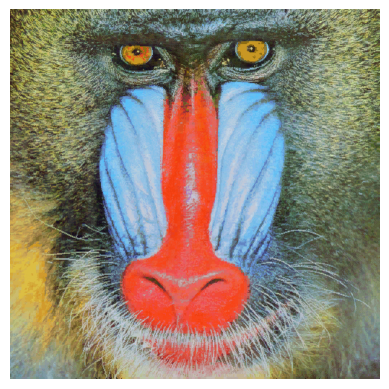

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('mandril.jpg')
if img is None:
    raise FileNotFoundError('La imagen del mandril no está disponible')

print('Dimensiones (alto, ancho, canales):', img.shape)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure()
plt.axis("off")
plt.imshow(img_rgb)
plt.show()

<a id="2.-TAREA-1"></a>

## 1. Recuento de píxeles blancos por filas utilizando Canny
### 1.1. Transformación de la imagen

Los detectores de bordes actúan en un único plano de intensidad. Por tanto, se convierte a una escala de grises la imagen. Para ello se emplea `cv2.cvtColor` con `COLOR_BGR2GRAY`, que calcula una media ponderada de los tres canales con `COLOR_BGR2GRAY`. Por otra parte, Canny es un detector de bordes que funciona en cuatro pasos: primero suaviza la imagen para eliminar ruido, después calcula dónde cambia  el brillo aplicando el gradiente de Sobel, luego adelgaza los bordes para que exista como grosor 1 pixel y, por último, decide qué píxeles son borde usando dos umbrales. Los valores que superan el umbral alto se conservan, los que no llegan al bajo se descartan y los intermedios solo se mantienen si están conectados a un borde seguro. `cv2.Canny(imagen, umbral_inferior, umbral_superior)` devuelve una imagen binaria con valores **0** (sin borde) o **255** (borde).

Valores distintos en la salida de Canny: [  0 255]


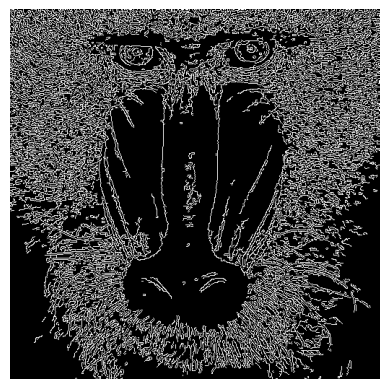

In [3]:
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Parámetros de la función: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200)
print('Valores distintos en la salida de Canny:', np.unique(canny))

plt.figure()
plt.axis("off")
plt.imshow(canny, cmap='gray')   # un solo plano: hay que indicar el mapa de grises
plt.show()

### 1.2. Resolución de la tarea 1

**Enunciado.** Realizar la cuenta de píxeles blancos por filas (en lugar de por columnas). Determinar el valor máximo de píxeles blancos para filas, `maxfil`, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que `0.90*maxfil`. Resaltar con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

maxfil = 220 píxeles blancos de 512
Filas con >= 0.90*maxfil: 7
Posiciones: [6, 12, 15, 20, 21, 88, 100]


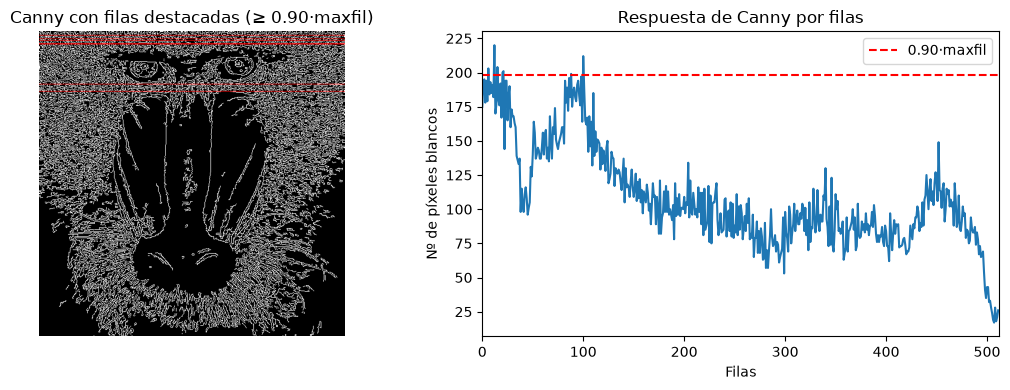

In [4]:
# Se cuenta el número máximo de píxeles blancos por filas
fil_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
ancho = canny.shape[1]
fils = fil_counts[:, 0] / 255 #número total de pixeles blancos por fila

# Valor máximo y umbral del 90 %
maxfil = np.max(fils)
umbral = 0.90 * maxfil

# Posiciones de las filas que cumplen la condicióm del umbral
filas_destacadas = np.where(fils >= 0.90 * maxfil)[0]
print(f"maxfil = {maxfil:.0f} píxeles blancos de {ancho}")
print(f"Filas con >= 0.90*maxfil: {len(filas_destacadas)}")
print("Posiciones:", filas_destacadas.tolist())

# Resalta con líneas rojas las filas seleccionadas
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
for i in filas_destacadas:
    cv2.line(canny_color, (0, int(i)), (ancho - 1, int(i)), (255, 0, 0), 1)

# Muestra la imagen resaltada y la cuenta por filas
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny con filas destacadas (≥ 0.90·maxfil)")
plt.imshow(canny_color)

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny por filas")
plt.xlabel("Filas")
plt.ylabel("Nº de píxeles blancos")
plt.plot(fils)
plt.axhline(umbral, color='r', linestyle='--', label="0.90·maxfil")
plt.xlim([0, canny.shape[0]]) 
plt.legend()
plt.tight_layout()
plt.savefig('resultados/tarea1_canny_filas.png', dpi=120, bbox_inches='tight')
plt.show()

<a id="3.-TAREA-2"></a>
## 2. Sobel umbralizado vs. Canny, recuento por filas y columnas

### 2.1. Preparación: Sobel en 8 bits
Sobel aproxima la derivada de la imagen con un kernel de tamaño impar basado en el patrón [1 2 1]: un borde es una zona donde la intensidad cambia bruscamente.

- `dx=1, dy=0` se relaciona con los bordes verticales y `dx=0, dy=1` se relaciona con los bordes horizontales; ambos se combinan con `cv2.add`.
- Antes se aplica un desenfoque gaussiano `(3,3)` para atenuar el ruido de alta frecuencia, que el derivador amplificaría.
- Se calcula en `CV_64F` porque la derivada puede ser negativa y superar 255.
- Para umbralizar y visualizar hay que convertir a 8 bits con `cv2.convertScaleAbs` (valor absoluto, redondeo y saturación a 255). Si se realizase la conversión con `np.uint8(np.abs(...))` se generaría un desbordamiento en los valores superiores a 255.

In [5]:
# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

# Derivadas en ambas direcciones (flotante de 64 bits: admiten negativos y valores > 255)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)   # bordes verticales
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)   # bordes horizontales
sobel = cv2.add(sobelx, sobely)               # combina ambos resultados

# Conversión a 8 bits (valor absoluto + saturación a 255)
sobel8 = cv2.convertScaleAbs(sobel)
print(f"sobel  -> {sobel.dtype}, mín: {np.min(sobel)}, máx: {np.max(sobel)}")
print(f"sobel8 -> {sobel8.dtype}, mín: {np.min(sobel8)}, máx: {np.max(sobel8)}")

sobel  -> float64, mín: -594.0, máx: 570.0
sobel8 -> uint8, mín: 0, máx: 255


### 2.2. Resolución de la tarea 2

**Enunciado.** Aplicar umbralizado a la imagen resultante de Sobel (convertida a 8 bits) y realizar el conteo por filas y columnas de píxeles no nulos, similar al realizado con la salida de Canny. Calcular el valor máximo de la cuenta por filas y columnas y determinar las filas y columnas por encima de 0.90·máximo. Remarcar con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualizar los resultados con Canny y Sobel tras umbralizar y compararlos.

**Pasos que sigue el planteamiento de la solución:**
1. Se umbraliza `sobel8` con `cv2.threshold` (`THRESH_BINARY`, valor 130): todo lo que supere el umbral pasa a 255 y el resto se convierte a 0.
2. Se cuentan los píxeles blancos que hay por columnas (`cv2.reduce` con `dim=0`) y por filas (`dim=1`), normalizando como en la tarea 1.
3. Se calculan el máximo de cada cuenta y el umbral del 90 %.
4. Se dibujan sobre una copia de la imagen del mandril (RGB) una línea horizontal por cada fila seleccionada y una vertical por cada columna seleccionada.

Sobel -> 7 filas y 1 columnas >= 0.90*máximo
Filas: [3, 4, 20, 51, 81, 82, 83]
Columnas: [288]


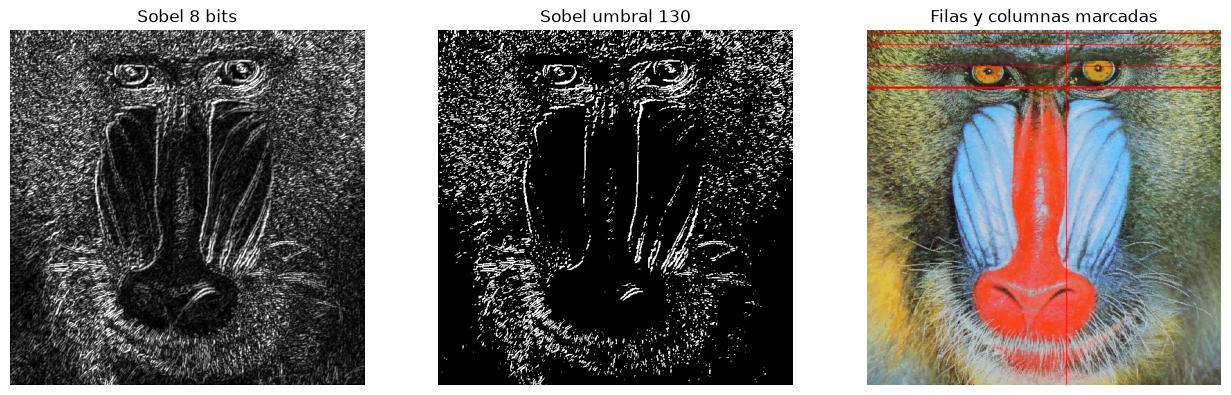

In [6]:
valorUmbral = 130

# 1. Umbralizado de la imagen de Sobel en 8 bits
_, imagenUmbralizada = cv2.threshold(sobel8, valorUmbral, 255, cv2.THRESH_BINARY)
alto, ancho = imagenUmbralizada.shape

# 2. Conteo de píxeles no nulos por columnas y por filas (número absoluto de píxeles)
col_counts = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols = col_counts[0] / 255

fil_counts = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
fils = fil_counts[:, 0] / 255

# 3. Valores máximos y umbrales del 90 %
maxfil = np.max(fils)
maxcol = np.max(cols)
umbralFil = 0.90 * maxfil
umbralCol = 0.90 * maxcol

filas_sobel = np.where(fils >= umbralFil)[0]
cols_sobel = np.where(cols >= umbralCol)[0]
print(f"Sobel -> {len(filas_sobel)} filas y {len(cols_sobel)} columnas >= 0.90*máximo")
print("Filas:", filas_sobel.tolist())
print("Columnas:", cols_sobel.tolist())

# 4. Remarca filas y columnas sobre una copia del mandril (RGB: (255,0,0) es rojo)
img_marcada = img_rgb.copy()
for i in filas_sobel:
    cv2.line(img_marcada, (0, int(i)), (ancho - 1, int(i)), (255, 0, 0), 1)
for j in cols_sobel:
    cv2.line(img_marcada, (int(j), 0), (int(j), alto - 1), (255, 0, 0), 1)

plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title("Sobel 8 bits")
plt.imshow(sobel8, cmap='gray')

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title(f"Sobel umbral {valorUmbral}")
plt.imshow(imagenUmbralizada, cmap='gray')

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title("Filas y columnas marcadas")
plt.imshow(img_marcada)
plt.tight_layout()
plt.savefig('resultados/tarea2_sobel.png', dpi=120, bbox_inches='tight')
plt.show()

**Canny.** Para comparar, se repite exactamente el mismo procedimiento (conteo por filas y columnas, máximo, umbral del 90 % y marcado sobre el mandril) sobre la salida de Canny, que ya es binaria (0/255). Se muestran los resultados de ambos detectores juntos.

Canny -> 7 filas y 19 columnas >= 0.90*máximo
Filas: [6, 12, 15, 20, 21, 88, 100]
Columnas: [67, 86, 92, 96, 99, 100, 103, 104, 105, 112, 115, 119, 123, 379, 380, 383, 392, 396, 403]


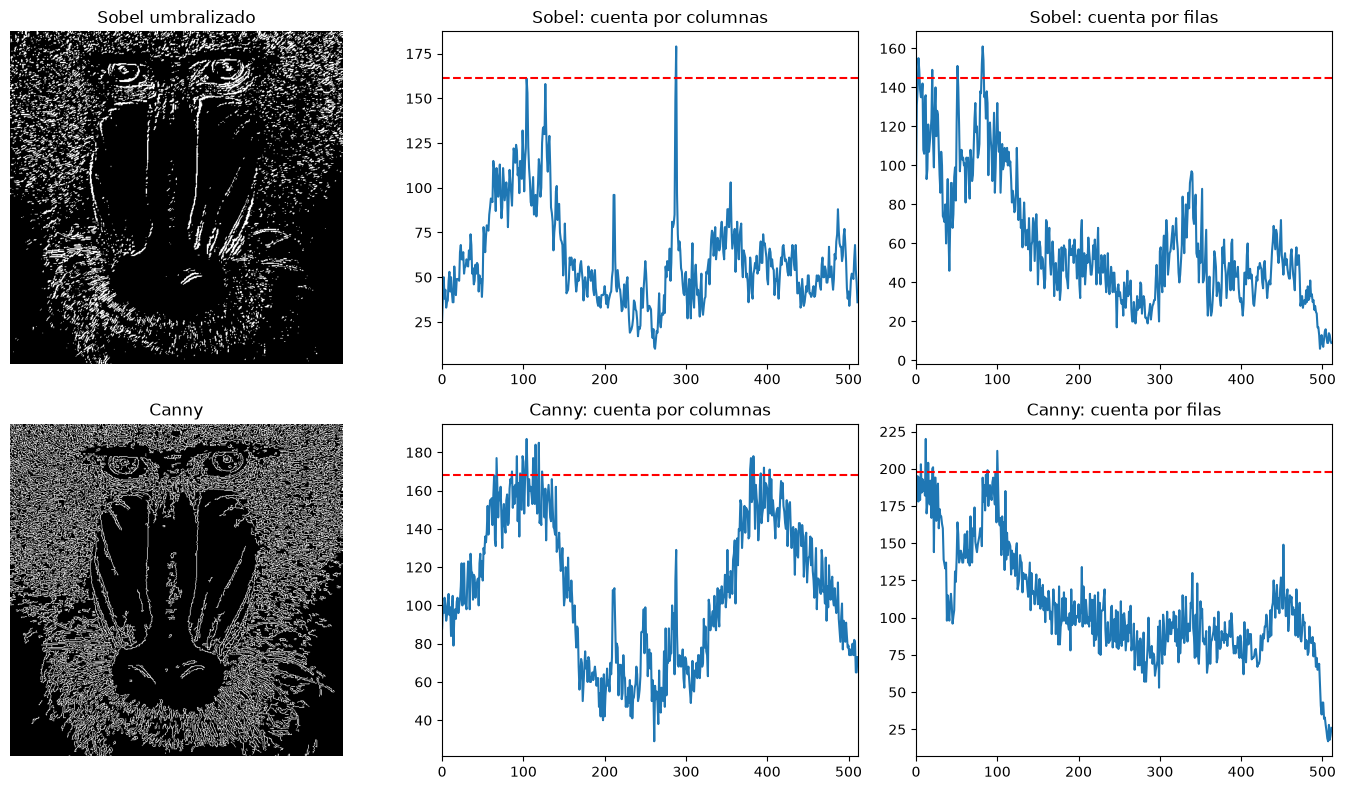

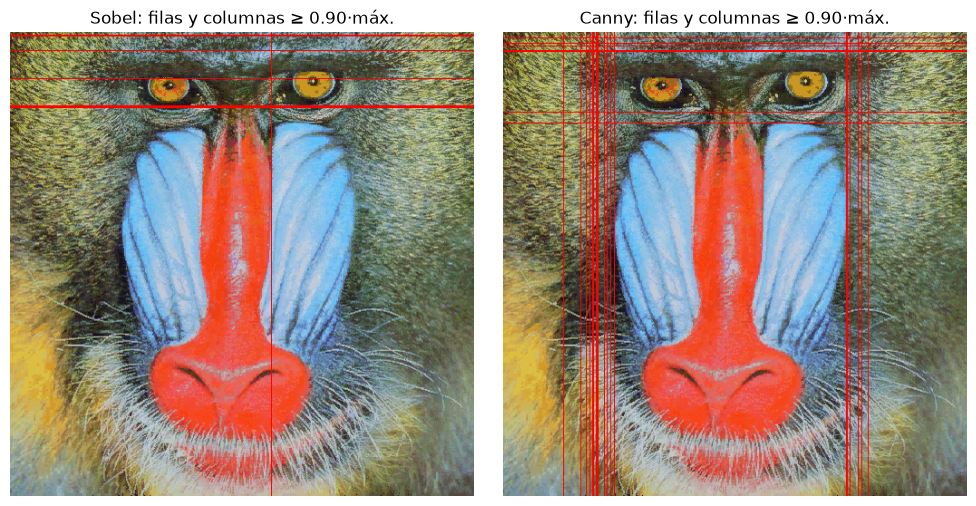


Detector              Px borde  % imagen  #filas  #cols
Sobel umbralizado        31199     11.9%       7      1
Canny                    55509     21.2%       7     19


In [7]:
# Mismo procedimiento sobre la salida de Canny (ya binaria: 0 o 255)
col_counts_c = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
cols_c = col_counts_c[0] / 255
fil_counts_c = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
fils_c = fil_counts_c[:, 0] / 255

maxfil_c = np.max(fils_c)
maxcol_c = np.max(cols_c)
filas_canny = np.where(fils_c >= 0.90 * maxfil_c)[0]
cols_canny = np.where(cols_c >= 0.90 * maxcol_c)[0]
print(f"Canny -> {len(filas_canny)} filas y {len(cols_canny)} columnas >= 0.90*máximo")
print("Filas:", filas_canny.tolist())
print("Columnas:", cols_canny.tolist())

img_marcada_c = img_rgb.copy()
for i in filas_canny:
    cv2.line(img_marcada_c, (0, int(i)), (ancho - 1, int(i)), (255, 0, 0), 1)
for j in cols_canny:
    cv2.line(img_marcada_c, (int(j), 0), (int(j), alto - 1), (255, 0, 0), 1)

# Comparación visual: arriba tenemos Sobel umbralizado, abajo Canny
plt.figure(figsize=(14, 8))
plt.subplot(2, 3, 1)
plt.axis("off")
plt.title("Sobel umbralizado")
plt.imshow(imagenUmbralizada, cmap='gray')
plt.subplot(2, 3, 2)
plt.title("Sobel: cuenta por columnas")
plt.plot(cols)
plt.axhline(umbralCol, color='r', linestyle='--')
plt.xlim([0, ancho])
plt.subplot(2, 3, 3)
plt.title("Sobel: cuenta por filas")
plt.plot(fils)
plt.axhline(umbralFil, color='r', linestyle='--')
plt.xlim([0, alto])

plt.subplot(2, 3, 4)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray')
plt.subplot(2, 3, 5)
plt.title("Canny: cuenta por columnas")
plt.plot(cols_c)
plt.axhline(0.90 * maxcol_c, color='r', linestyle='--')
plt.xlim([0, ancho])
plt.subplot(2, 3, 6)
plt.title("Canny: cuenta por filas")
plt.plot(fils_c)
plt.axhline(0.90 * maxfil_c, color='r', linestyle='--')
plt.xlim([0, alto])
plt.tight_layout()
plt.savefig('resultados/tarea2_comparacion.png', dpi=120, bbox_inches='tight')
plt.show()

# Mandril con las marcas de cada detector
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel: filas y columnas ≥ 0.90·máx.")
plt.imshow(img_marcada)
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("Canny: filas y columnas ≥ 0.90·máx.")
plt.imshow(img_marcada_c)
plt.tight_layout()
plt.savefig('resultados/tarea2_marcas.png', dpi=120, bbox_inches='tight')
plt.show()

# Resumen
print(f"\n{'Detector':<20}{'Px borde':>10}{'% imagen':>10}{'#filas':>8}{'#cols':>7}")
for nombre, binaria, nf, nc in [("Sobel umbralizado", imagenUmbralizada, len(filas_sobel), len(cols_sobel)),
                                ("Canny", canny, len(filas_canny), len(cols_canny))]:
    n = int(np.count_nonzero(binaria))
    print(f"{nombre:<20}{n:>10}{100 * n / binaria.size:>9.1f}%{nf:>8}{nc:>7}")

<a id="3.-TAREA-3"></a>
## 3. Demostrador de imágeneces interactivo "Movement Counter"

Como reinterpretación de la instalación interactiva *Virtual Air Guitar* (donde la interacción en distintas zonas del espacio generan respuestas), proponemos un demostrador fitness basado en la creación de rectángulos espaciales interativos.

Para poder usarse el usuario tiene que situarse frente a la cámara y debe mover sus manos alternando entre las regiones dibujadas en pantalla (arriba y abajo, tanto para el brazo izquierdo como el derecho). El sistema detecta la interacción midiendo la cantidad de movimiento dentro de esas regiones de forma independiente para contabilizar las repeticiones.

Para su creación, el sistema se basa íntegramente en las herramientas adquiridas en la práctica 1 y 2:
1. **Sustracción de fotogramas (`cv2.absdiff`):** Explicado en la práctica 2 para detectar movimiento. Aislamos qué partes de la imagen están cambiando en tiempo real.
2. **Umbralizado (`cv2.threshold`):** Para binarizar esa diferencia y obtener una máscara clara de movimiento.
3. **Slicing de matrices (NumPy):** Concepto de la práctica 1, que se utiliza para aislar lascajas de interacción e ignorar el movimiento en el resto del espacio.
4. **Primitivas de OpenCV:** Uso de `cv2.rectangle` y `cv2.putText` para construir la interfaz visual interactiva.

En la siguiente celda, se muestra la lógica para manejar el estado de cada brazo de forma independiente:

In [8]:
def crear_brazo():
    return {
        "estado": "centro",
        "repeticiones": 0,
        "color_arriba": (0, 0, 255),  # Rojo inactivo
        "color_abajo": (0, 0, 255)
    }

def actualizar_brazo(brazo, mov_arriba, mov_abajo, umbral):
    # Reset colores a inactivo por defecto
    brazo["color_arriba"] = (0, 0, 200)
    brazo["color_abajo"] = (0, 0, 200)
    
    if mov_arriba > umbral:
        brazo["color_arriba"] = (0, 255, 0) # Verde activo
        if brazo["estado"] == "abajo":
            brazo["estado"] = "arriba"
            brazo["repeticiones"] += 1
        else:
            brazo["estado"] = "arriba"
            
    elif mov_abajo > umbral:
        brazo["color_abajo"] = (0, 255, 0) # Verde activo
        brazo["estado"] = "abajo"


En esta segunda y última celda se procesa la diferencia de fotogramas, se recorta la matriz en las regiones de interés (ROIs) y se actualiza la interfaz sobre el fotograma original.

In [9]:
vid = cv2.VideoCapture(0)

# Inicializamos los dos brazos
brazo_izq = crear_brazo()
brazo_der = crear_brazo()
frame_previo = None

# Coordenadas de las zonas (y_inicio, y_fin, x_inicio, x_fin)
ZONAS = {
    "izq_arriba": [120, 240, 50, 200],
    "izq_abajo":  [320, 440, 50, 200],
    "der_arriba": [120, 240, 440, 590],
    "der_abajo":  [320, 440, 440, 590]
}

SENSIBILIDAD = 1200  # Número mínimo de pixeles en movimiento

while True:      
    ret, frame = vid.read()
    if not ret: break
        
    # Efecto espejo y fijar tamaño
    frame = cv2.flip(cv2.resize(frame, (640, 480)), 1)
    gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    if frame_previo is None:
        frame_previo = gris.copy()
        continue

    # 1. Extrae el movimiento
    diferencia = cv2.absdiff(gris, frame_previo) # resta la imagen actual de la anterior
    _, mascara = cv2.threshold(diferencia, 25, 255, cv2.THRESH_BINARY) #se limpia el ruido
    
    # 2.Evaluación de las regiones de interés
    cantidades = {}
    for clave, coords in ZONAS.items():
        movimiento_zona = mascara[coords[0]:coords[1], coords[2]:coords[3]] # extrae únicamente el trozo de la matriz que corresponde a esa caja
        cantidades[clave] = np.sum(movimiento_zona) / 255  #cuantos pixeles se han movido dentro de la caja
        
    # 3. Actualización de estado
    actualizar_brazo(brazo_izq, cantidades["izq_arriba"], cantidades["izq_abajo"], SENSIBILIDAD)
    actualizar_brazo(brazo_der, cantidades["der_arriba"], cantidades["der_abajo"], SENSIBILIDAD)

    # 4. Renderizado
    # Dibujar Cajas Izquierdas
    zi_u = ZONAS["izq_arriba"]
    cv2.rectangle(frame, (zi_u[2], zi_u[0]), (zi_u[3], zi_u[1]), brazo_izq["color_arriba"], 3)
    zi_d = ZONAS["izq_abajo"]
    cv2.rectangle(frame, (zi_d[2], zi_d[0]), (zi_d[3], zi_d[1]), brazo_izq["color_abajo"], 3)
    
    # Dibujar Cajas Derechas
    zd_u = ZONAS["der_arriba"]
    cv2.rectangle(frame, (zd_u[2], zd_u[0]), (zd_u[3], zd_u[1]), brazo_der["color_arriba"], 3)
    zd_d = ZONAS["der_abajo"]
    cv2.rectangle(frame, (zd_d[2], zd_d[0]), (zd_d[3], zd_d[1]), brazo_der["color_abajo"], 3)

    # Textos de la pantalla
    # Izquierdo
    cv2.putText(frame, f"IZQ: {brazo_izq['repeticiones']}", (60, 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)
    # Derecho
    cv2.putText(frame, f"DER: {brazo_der['repeticiones']}", (460, 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 3)
    # Titulo central
    cv2.putText(frame, "Movement Counter", (220, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

    cv2.imshow('Demostrador Interactivo', frame)
    
    frame_previo = gris.copy()
    
    tecla = cv2.waitKey(20)
    if tecla == 27:                
        break
    elif tecla in (ord('r'), ord('R')):
        brazo_izq = crear_brazo()
        brazo_der = crear_brazo()
  
vid.release()
cv2.destroyAllWindows()
